#Module 9 — Regression Models on Housing Dataset

### Linear Regression · Ridge Regression · Lasso Regression · MSE · RMSE · R² · MAE

#### **Load the Dataset**

In [1]:
import numpy as np
import pandas as pd

In [2]:
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data"

In [3]:
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

In [4]:
df = pd.read_csv(data_url, sep=r'\s+', header=None, names=columns)

In [5]:
print(df.head(5))

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [7]:
print(df.shape)

(506, 14)


In [9]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


####**Split the Dataset**

In [13]:
from sklearn.model_selection import train_test_split

In [10]:
X=df.drop(columns=['MEDV'])
y=df['MEDV']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) #train (80%) and test (20%)

In [16]:
print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Training size: 404
Test size: 102


####**Train All Three Models**

In [17]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [18]:
lr=LinearRegression()
ridge=Ridge(alpha=1.0)
lasso=Lasso(alpha=0.1)

In [22]:
## Train (fit) each model on training data
lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
print("All models trained successfully!")

All models trained successfully!


#### **Evaluate Models**

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [31]:
def evaluate_model(name,model, X_test, y_test):
  y_pred=model.predict(X_test)
  mse=mean_squared_error(y_test, y_pred)
  rmse=np.sqrt(mse)
  r2=r2_score(y_test, y_pred)
  mae=mean_absolute_error(y_test, y_pred)

  return {
        'Model': name,
        'MSE'  : round(mse,  4),
        'RMSE' : round(rmse, 4),
        'R²'   : round(r2,   4),
        'MAE'  : round(mae,  4)
    }


In [35]:
results = [
    evaluate_model('Linear Regression', lr,  X_test, y_test),
    evaluate_model('Ridge Regression',  ridge,  X_test, y_test),
    evaluate_model('Lasso Regression',  lasso, X_test, y_test)
]

results


[{'Model': 'Linear Regression',
  'MSE': 24.2911,
  'RMSE': np.float64(4.9286),
  'R²': 0.6688,
  'MAE': 3.1891},
 {'Model': 'Ridge Regression',
  'MSE': 24.4772,
  'RMSE': np.float64(4.9474),
  'R²': 0.6662,
  'MAE': 3.1329},
 {'Model': 'Lasso Regression',
  'MSE': 25.1556,
  'RMSE': np.float64(5.0155),
  'R²': 0.657,
  'MAE': 3.1452}]

#### **Compare Results**

In [40]:
# make dataframe
results_df=pd.DataFrame(results)
results_df=results_df.set_index("Model")

print("-----------Model Comparison-----------")
print("-------------------------------------")
print(results_df.to_string())

-----------Model Comparison-----------
-------------------------------------
                       MSE    RMSE      R²     MAE
Model                                             
Linear Regression  24.2911  4.9286  0.6688  3.1891
Ridge Regression   24.4772  4.9474  0.6662  3.1329
Lasso Regression   25.1556  5.0155  0.6570  3.1452


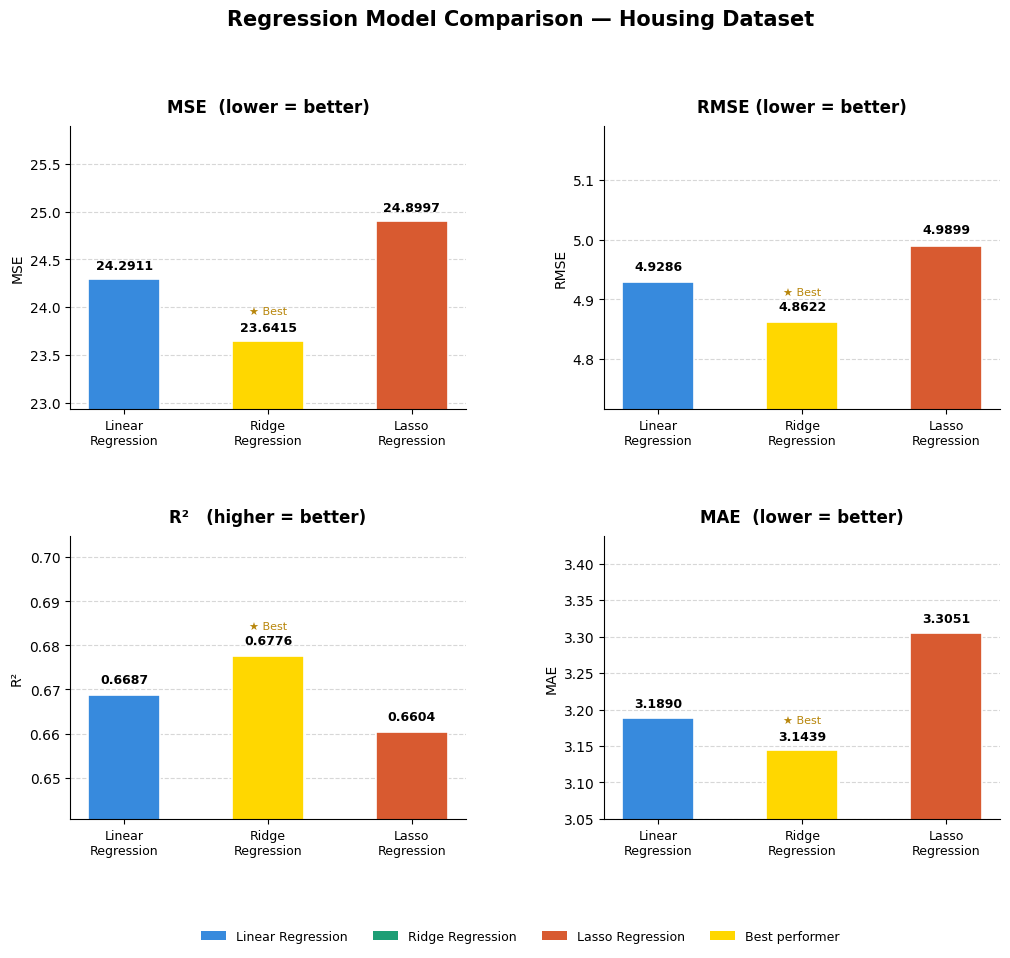

In [46]:
import matplotlib.pyplot as plt

# ── Data ──────────────────────────────────────────────────
models  = ['Linear\nRegression', 'Ridge\nRegression', 'Lasso\nRegression']
mse_v   = [24.2911, 23.6415, 24.8997]
rmse_v  = [4.9286,  4.8622,  4.9899]
r2_v    = [0.6687,  0.6776,  0.6604]
mae_v   = [3.1890,  3.1439,  3.3051]

colors  = ['#378ADD', '#1D9E75', '#D85A30']
x       = np.arange(len(models))
width   = 0.5

# ── Figure setup ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Regression Model Comparison — Housing Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# ── Helper to draw one bar chart ──────────────────────────
def draw_bar(ax, values, title, ylabel, highlight_min=True):
    best_idx = values.index(min(values)) if highlight_min else values.index(max(values))
    bar_colors = ['#FFD700' if i == best_idx else colors[i]
                  for i in range(len(values))]
    bars = ax.bar(x, values, width, color=bar_colors,
                  edgecolor='white', linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9)
    ax.set_ylim(min(values) * 0.97, max(values) * 1.04)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
               bar.get_height() + (bar.get_height() * 0.003),
               f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.bar_label(bars, labels=['★ Best' if i == best_idx else ''
                               for i in range(len(values))],
                padding=18, fontsize=8, color='#B8860B')

# ── Plot all 4 metrics ────────────────────────────────────
draw_bar(axes[0,0], mse_v,  'MSE  (lower = better)',  'MSE',  highlight_min=True)
draw_bar(axes[0,1], rmse_v, 'RMSE (lower = better)',  'RMSE', highlight_min=True)
draw_bar(axes[1,0], r2_v,  'R²   (higher = better)', 'R²',   highlight_min=False)
draw_bar(axes[1,1], mae_v, 'MAE  (lower = better)',  'MAE',  highlight_min=True)

# ── Legend ────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor=colors[0], label='Linear Regression'),
    Patch(facecolor=colors[1], label='Ridge Regression'),
    Patch(facecolor=colors[2], label='Lasso Regression'),
    Patch(facecolor='#FFD700', label='Best performer'),
]
fig.legend(handles=legend_els, loc='lower center',
           ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
